<a href="https://colab.research.google.com/github/mohduzr02/DCF-MODEL/blob/main/Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing library
Pandas
Numpy
SciKit Learn
Yfinance
Statsmodel
Matplotlib
Seaborn

In [437]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection as sklearn
import statsmodels.api as sm
import yfinance as yf


## Downloading Data
Downloading data from web using yfinance ,cctx

Ticker:^NSEI,BTC-INR,^GSPC,INR=X,GC=F,USDINR=X,GOLDBEES.NS,LTGILTBEES.NS

In [438]:
Ticker = ['^NSEI','BTC-INR','^GSPC','USDINR=X','GOLDBEES.NS','LTGILTBEES.NS']
df_s = yf.download(Ticker,start="2019-06-01",interval="1wk",auto_adjust= True)

[*********************100%***********************]  6 of 6 completed


## Cleaning Data
making data tidy


In [439]:
df_s.head(5)

Price             Close                                                    \
Ticker          BTC-INR GOLDBEES.NS LTGILTBEES.NS   USDINR=X        ^GSPC   
Date                                                                        
2019-05-27  608332.1250         NaN           NaN  69.980003          NaN   
2019-06-03  533207.9375   28.906500           NaN  69.360001  2873.340088   
2019-06-10  627632.2500   29.242001           NaN  69.859001  2886.979980   
2019-06-17  755315.6250   29.764999         19.35  69.779999  2950.459961   
2019-06-24  745848.3125   29.979500         19.40  69.324997  2941.760010   

Price                            High                                       \
Ticker             ^NSEI      BTC-INR GOLDBEES.NS LTGILTBEES.NS   USDINR=X   
Date                                                                         
2019-05-27           NaN  612945.1875         NaN           NaN  69.980003   
2019-06-03  11870.650391  608377.1250   29.080000           NaN  69.625000   
2019-06-10  11823.299805  652381.0625   29.350000           NaN  69.842003   
2019-06-17  11724.099609  782619.1875   30.485001         19.51  70.112503   
2019-06-24  11788.849609  954577.3750   30.600000         20.40  69.769997   

Price       ...          Open                                        \
Ticker      ... LTGILTBEES.NS   USDINR=X        ^GSPC         ^NSEI   
Date        ...                                                       
2019-05-27  ...           NaN  69.804001          NaN           NaN   
2019-06-03  ...           NaN  69.570503  2751.530029  11953.750000   
2019-06-10  ...           NaN  69.348000  2885.830078  11934.900391   
2019-06-17  ...         19.41  69.825996  2889.750000  11844.000000   
2019-06-24  ...         19.90  69.608002  2951.419922  11725.799805   

Price               Volume                                                   \
Ticker             BTC-INR GOLDBEES.NS LTGILTBEES.NS USDINR=X         ^GSPC   
Date                                                                          
2019-05-27   2974837041750         NaN           NaN        0           NaN   
2019-06-03   9711513949360   8287800.0           NaN        0  1.802677e+10   
2019-06-10   9406958260890   8164300.0           NaN        0  1.589421e+10   
2019-06-17   9494838400010   9337900.0       32698.0        0  1.851676e+10   
2019-06-24  15305445145820  11723400.0       78448.0        0  1.881289e+10   

Price                  
Ticker          ^NSEI  
Date                   
2019-05-27        NaN  
2019-06-03  1322200.0  
2019-06-10  1757400.0  
2019-06-17  2018300.0  
2019-06-24  1690100.0  

[5 rows x 30 columns]

In [440]:
df_s=df_s.drop(columns=["High","Low","Open","Volume"], axis=1)

In [441]:
df_s.to_csv('Dataset.csv')

In [442]:
print(df_s.shape)
print()
print(df_s.dtypes)
print()
print(df_s.isnull().sum())


(384, 6)

Price  Ticker       
Close  BTC-INR          float64
       GOLDBEES.NS      float64
       LTGILTBEES.NS    float64
       USDINR=X         float64
       ^GSPC            float64
       ^NSEI            float64
dtype: object

Price  Ticker       
Close  BTC-INR          0
       GOLDBEES.NS      1
       LTGILTBEES.NS    3
       USDINR=X         0
       ^GSPC            1
       ^NSEI            1
dtype: int64


In [443]:
df_s=  df_s.dropna()

In [444]:
print(df_s.isnull().sum())

Price  Ticker       
Close  BTC-INR          0
       GOLDBEES.NS      0
       LTGILTBEES.NS    0
       USDINR=X         0
       ^GSPC            0
       ^NSEI            0
dtype: int64


In [445]:
df_s.describe()

Price          Close                                                     \
Ticker       BTC-INR GOLDBEES.NS LTGILTBEES.NS    USDINR=X        ^GSPC   
count   3.810000e+02  381.000000    381.000000  381.000000   381.000000   
mean    3.957268e+06   59.414024     24.428005   80.775199  4747.250998   
std     2.847653e+06   27.292281      3.054949    6.942668  1333.603640   
min     3.986302e+05    0.336500     19.350000   68.440002  2304.919922   
25%     1.610797e+06   41.919998     22.240000   74.467300  3841.939941   
50%     3.165758e+06   48.380001     23.190001   82.100502  4411.790039   
75%     6.004626e+06   65.070000     27.080000   84.556999  5738.169922   
max     1.096001e+07  131.600006     30.120001   96.559998  7785.759766   

Price                 
Ticker         ^NSEI  
count     381.000000  
mean    18621.849350  
std      5011.928494  
min      8083.799805  
25%     14924.250000  
50%     18069.000000  
75%     23547.750000  
max     26328.550781

## Statistical Anlalysis on return

In [446]:

bad_date=df_return[('Close',"GOLDBEES.NS")].idxmax()
print(bad_date)
df_s.loc['2019-12-23', ('Close','GOLDBEES.NS')] = np.nan
df_s[('Close','GOLDBEES.NS')] = df_s[('Close','GOLDBEES.NS')].interpolate()

2026-01-19 00:00:00


In [447]:
# Finding Corrupted price Date of gold (MAX)
g = df_s[('Close', 'GOLDBEES.NS')]
local_median = g.rolling(5, center=True, min_periods=1).median()
bad = (g / local_median - 1).abs() > 0.25
print('Corrupted dates:', [d.date() for d in g.index[bad]])   # expect 2019-12-16 and 2019-12-23

df_s.loc[bad, ('Close', 'GOLDBEES.NS')] = np.nan
df_s[('Close', 'GOLDBEES.NS')] = df_s[('Close', 'GOLDBEES.NS')].interpolate()

df_return = df_s.pct_change().dropna()
assert df_return[('Close', 'GOLDBEES.NS')].abs().max() < 0.5

Corrupted dates: [datetime.date(2019, 12, 16), datetime.date(2019, 12, 23)]


In [448]:
#finding and Fixing price of each flagged week
g = df_s[('Close', 'GOLDBEES.NS')]
r = g.pct_change()
bad = r[r.abs() > 0.5]
print(bad, '\n')

for d in bad.index:
    i = g.index.get_loc(d)
    print(g.iloc[max(i - 3, 0): i + 4], '\n')   # prices around each flagged week

Series([], Freq: W-MON, Name: (Close, GOLDBEES.NS), dtype: float64) 



In [449]:
# Return Calculation
df_return = df_s.pct_change().round(4).dropna()

In [450]:
print(df_return.describe())

Price        Close                                                    \
Ticker     BTC-INR GOLDBEES.NS LTGILTBEES.NS    USDINR=X       ^GSPC   
count   380.000000  380.000000    380.000000  380.000000  380.000000   
mean      0.009423    0.003912      0.001133    0.000866    0.002837   
std       0.079574    0.020620      0.006335    0.006651    0.025433   
min      -0.335700   -0.071100     -0.039400   -0.023400   -0.149800   
25%      -0.028100   -0.008250     -0.001725   -0.002500   -0.010300   
50%       0.004100    0.003800      0.001000    0.000500    0.004650   
75%       0.052650    0.014825      0.003700    0.004100    0.015800   
max       0.273600    0.081800      0.037400    0.030200    0.121000   

Price               
Ticker       ^NSEI  
count   380.000000  
mean      0.001957  
std       0.022958  
min      -0.121500  
25%      -0.010600  
50%       0.003300  
75%       0.015025  
max       0.127200  


## Naming the assets

In [451]:
df = df_return.copy()
df.columns = df.columns.get_level_values(1)  # BTC-INR, GOLDBEES.NS etc
df = df.rename(columns={
    'BTC-INR':'BTC',
    'GOLDBEES.NS':'Gold',
    'LTGILTBEES.NS':'Bond',
    'USDINR=X':'USDINR',
    '^GSPC':'SP500',
    '^NSEI':'Nifty'
})

df.to_csv("Final price.csv")

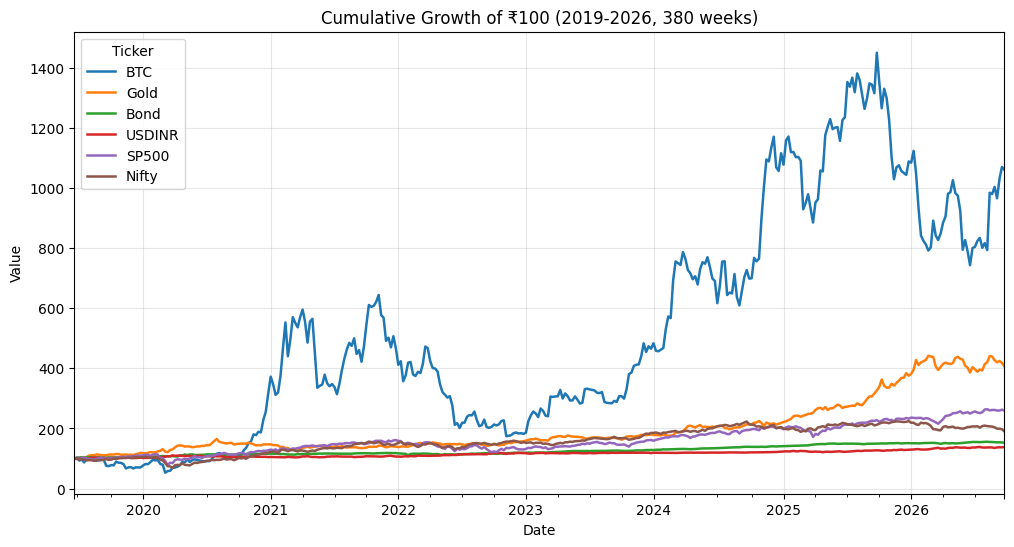

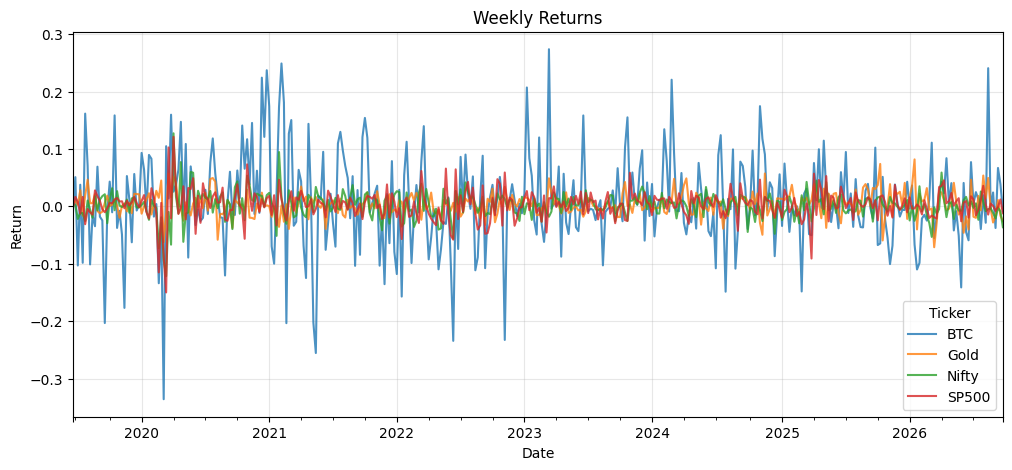

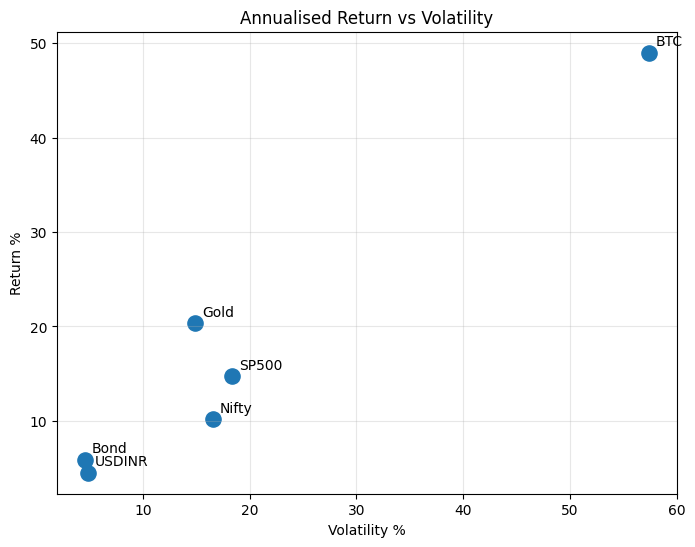

In [452]:
N = len(df)   # number of weekly observations (380 after the Gold repair)

# 1. Cumulative growth of Rs 100
cum_wealth = (1 + df).cumprod() * 100
cum_wealth.plot(figsize=(12, 6), linewidth=1.8)
plt.title(f'Cumulative Growth of ₹100 ({df.index[0].year}-{df.index[-1].year}, {N} weeks)')
plt.ylabel('Value')
plt.grid(alpha=0.3)
plt.show()

# 2. Weekly returns
df[['BTC', 'Gold', 'Nifty', 'SP500']].plot(figsize=(12, 5), alpha=0.8)
plt.title('Weekly Returns')
plt.ylabel('Return')
plt.grid(alpha=0.3)
plt.show()

# 3. Return vs risk (separate names, so the decimal ann_ret / ann_vol used later are not overwritten)
ret_pct = df.mean() * 52 * 100
vol_pct = df.std() * np.sqrt(52) * 100

plt.figure(figsize=(8, 6))
plt.scatter(vol_pct, ret_pct, s=120)
for asset in ret_pct.index:
    plt.annotate(asset, (vol_pct[asset], ret_pct[asset]), xytext=(5, 5), textcoords='offset points')
plt.xlabel('Volatility %')
plt.ylabel('Return %')
plt.title('Annualised Return vs Volatility')
plt.grid(alpha=0.3)
plt.show()

In [453]:
## Correlation Matrix
corr = df.corr().round(3)
print(corr)

Ticker    BTC   Gold   Bond  USDINR  SP500  Nifty
Ticker                                           
BTC     1.000  0.091  0.002  -0.010  0.257  0.204
Gold    0.091  1.000  0.086   0.067  0.138  0.067
Bond    0.002  0.086  1.000  -0.048  0.096  0.023
USDINR -0.010  0.067 -0.048   1.000 -0.294 -0.347
SP500   0.257  0.138  0.096  -0.294  1.000  0.559
Nifty   0.204  0.067  0.023  -0.347  0.559  1.000


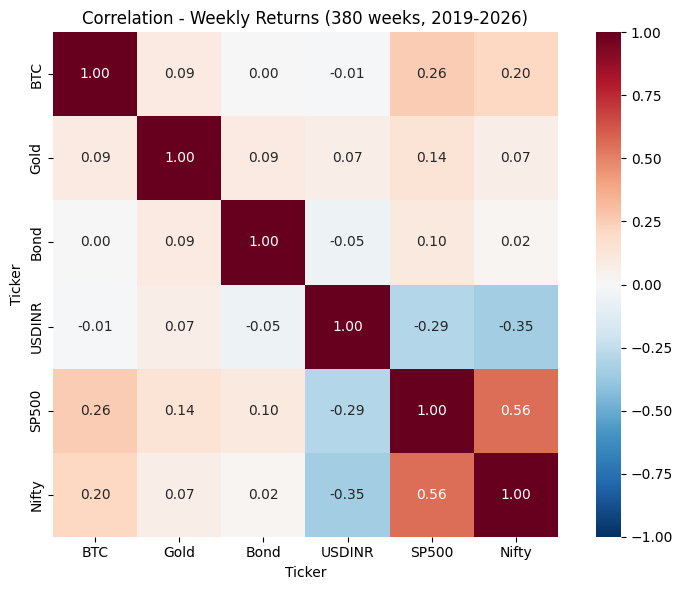

In [454]:
# 3. Graph
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True, fmt='.2f')
plt.title('Correlation - Weekly Returns (380 weeks, 2019-2026)')
plt.tight_layout()
plt.show()

In [455]:
# Covarance matrix
ann_covv = df.cov()*52
print(ann_covv)

Ticker       BTC      Gold      Bond    USDINR     SP500     Nifty
Ticker                                                            
BTC     0.329266  0.007774  0.000055 -0.000262  0.026995  0.019418
Gold    0.007774  0.022110  0.000585  0.000481  0.003757  0.001657
Bond    0.000055  0.000585  0.002087 -0.000106  0.000802  0.000177
USDINR -0.000262  0.000481 -0.000106  0.002300 -0.002584 -0.002756
SP500   0.026995  0.003757  0.000802 -0.002584  0.033635  0.016987
Nifty   0.019418  0.001657  0.000177 -0.002756  0.016987  0.027407


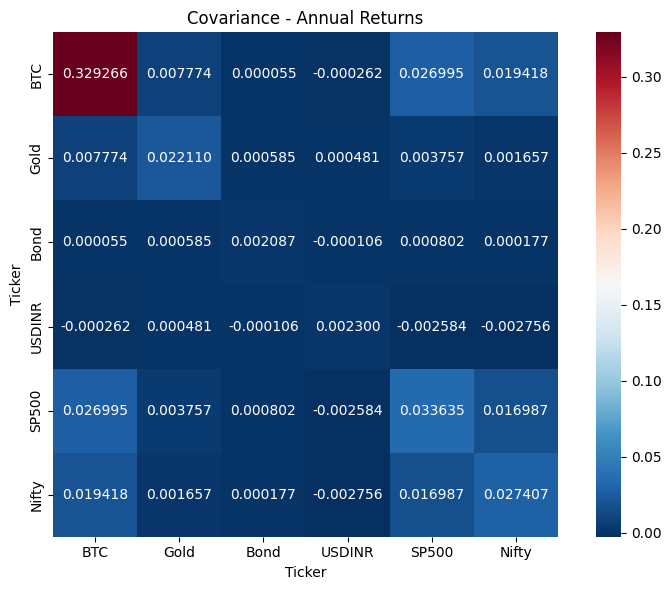

In [456]:
# 3. Graph
plt.figure(figsize=(8,6))
sns.heatmap(ann_covv, annot=True, cmap='RdBu_r', square=True, fmt='.6f')
plt.title('Covariance - Annual Returns')
plt.tight_layout()
plt.show()

## Annualized Return
using simple airthmatic return avgret*no . of week in years
Rf = 7.12%

In [457]:
# Annualized return and Standard Deviation
Rf = 0.065
ann_ret = df.mean() * 52
ann_std = df.std() * np.sqrt(52)

summary = pd.DataFrame({
    'Ann_Return': ann_ret * 100,
    'Ann_Vol': ann_std * 100,
}).round(2)
print(summary)

        Ann_Return  Ann_Vol
Ticker                     
BTC          49.00    57.38
Gold         20.34    14.87
Bond          5.89     4.57
USDINR        4.50     4.80
SP500        14.75    18.34
Nifty        10.17    16.56


In [458]:
df.describe()

Ticker,BTC,Gold,Bond,USDINR,SP500,Nifty
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
mean,0.009423,0.003912,0.001133,0.000866,0.002837,0.001957
std,0.079574,0.020620,0.006335,0.006651,0.025433,0.022958
min,-0.335700,-0.071100,-0.039400,-0.023400,-0.149800,-0.121500
25%,-0.028100,-0.008250,-0.001725,-0.002500,-0.010300,-0.010600
50%,0.004100,0.003800,0.001000,0.000500,0.004650,0.003300
75%,0.052650,0.014825,0.003700,0.004100,0.015800,0.015025
max,0.273600,0.081800,0.037400,0.030200,0.121000,0.127200


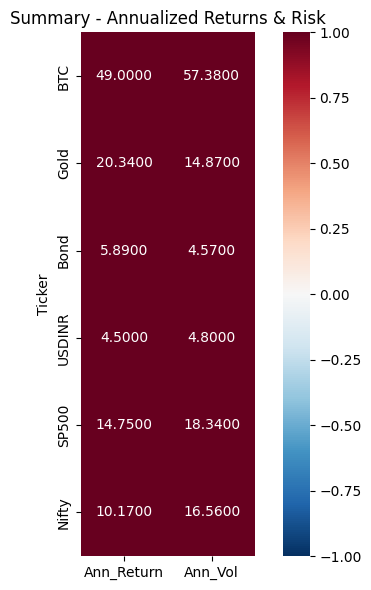

In [459]:
# 3. Graph
plt.figure(figsize=(6,6))
sns.heatmap(summary, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True, fmt='.4f')
plt.title('Summary - Annualized Returns & Risk')
plt.tight_layout()
plt.show()

## Portfolio Construction and Analysis (MPT)


In [460]:
# Risk free rate
Rf = 0.065


# final_df with 5 assets for Indian investor

assets = ['BTC','Gold','Bond','USDINR','Nifty']
final_df = df[assets].copy()

print(final_df.head())

Ticker         BTC    Gold    Bond  USDINR   Nifty
Date                                              
2019-06-24 -0.0125  0.0072  0.0026 -0.0065  0.0055
2019-07-01  0.0509  0.0089  0.0124 -0.0128  0.0019
2019-07-08 -0.1029  0.0027  0.0168  0.0016 -0.0219
2019-07-15  0.0377  0.0282  0.0060  0.0053 -0.0115
2019-07-22 -0.0982 -0.0160 -0.0114  0.0034 -0.0118


In [461]:
# ANNUAL RETURN , RISK AND COVV

ann_ret = final_df.mean() * 52  # arithmetic, for frontier
ann_vol = final_df.std() * np.sqrt(52) # volatility
cov_ann = final_df.cov() * 52  # for portfolio vol

# For thesis reporting - CAGR
cagr = (1+final_df).prod()**(52/378) - 1

summary = pd.DataFrame({
    'CAGR_%': cagr*100,
    'Arith_%': ann_ret*100,
    'Vol_%': ann_vol*100
}).round(2)

print(summary)

        CAGR_%  Arith_%  Vol_%
Ticker                        
BTC      38.38    49.00  57.38
Gold     21.30    20.34  14.87
Bond      5.99     5.89   4.57
USDINR    4.51     4.50   4.80
Nifty     9.25    10.17  16.56


In [462]:
# Portfolio construction
# Order = [BTC, Gold, Bond, USDINR,Nifty]

portfolios = {
    'P1: 100% Nifty': [0, 0, 0, 0, 1.0],
    'P2: 60% Nifty + 40% Bond': [0, 0, 0.4, 0, 0.6],
    'P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD': [0, 0.20, 0.20, 0.10, 0.50],
    'P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC': [0.10, 0.20, 0.10, 0.20, 0.40],
    'P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC)': [0.20, 0.20, 0.10, 0.10, 0.40],
    'P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC': [0, 0.30, 0.20, 0.10, 0.40],
}




# P1, P2, P3, P4, P5 , P6
print("Final 6 portfolios:")
for k,v in portfolios.items():
    print(k, v)

Final 6 portfolios:
P1: 100% Nifty [0, 0, 0, 0, 1.0]
P2: 60% Nifty + 40% Bond [0, 0, 0.4, 0, 0.6]
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD [0, 0.2, 0.2, 0.1, 0.5]
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC [0.1, 0.2, 0.1, 0.2, 0.4]
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC) [0.2, 0.2, 0.1, 0.1, 0.4]
P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC [0, 0.3, 0.2, 0.1, 0.4]


## Portfolio Performance
sharpe ratio = rp-rf/total risk

sortino ratio = rp-rf/ downside deviation

calmar = CAGR/Max Drawdown

In [463]:
# Portfolio Return Risk
Rf = 0.065                                   # annual risk-free rate (decimal)
mu  = final_df.mean() * 52                   # 5-asset annual arithmetic return
cov = final_df.cov() * 52                    # 5x5 annual covariance

results = []
for name, w in portfolios.items():
    w = np.array(w)
    p_ret = (w @ mu.values) * 100            # %
    p_vol = np.sqrt(w @ cov.values @ w) * 100
    results.append([name, p_ret, p_vol, (p_ret - Rf * 100) / p_vol])

df_Port_ret = pd.DataFrame(results, columns=['Portfolio', 'Portfolio_Return', 'Portfolio_Risk',
                                             'Sharpe Ratio (with Rf)'])
print(df_Port_ret.round(2))

                                           Portfolio  Portfolio_Return  \
0                                     P1: 100% Nifty             10.17   
1                           P2: 60% Nifty + 40% Bond              8.46   
2      P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD             10.78   
3  P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD ...             14.53   
4  P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD ...             18.98   
5  P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD ...             11.80   

   Portfolio_Risk  Sharpe Ratio (with Rf)  
0           16.56                    0.22  
1           10.14                    0.19  
2            8.94                    0.48  
3           10.21                    0.79  
4           14.93                    0.84  
5            8.24                    0.64  


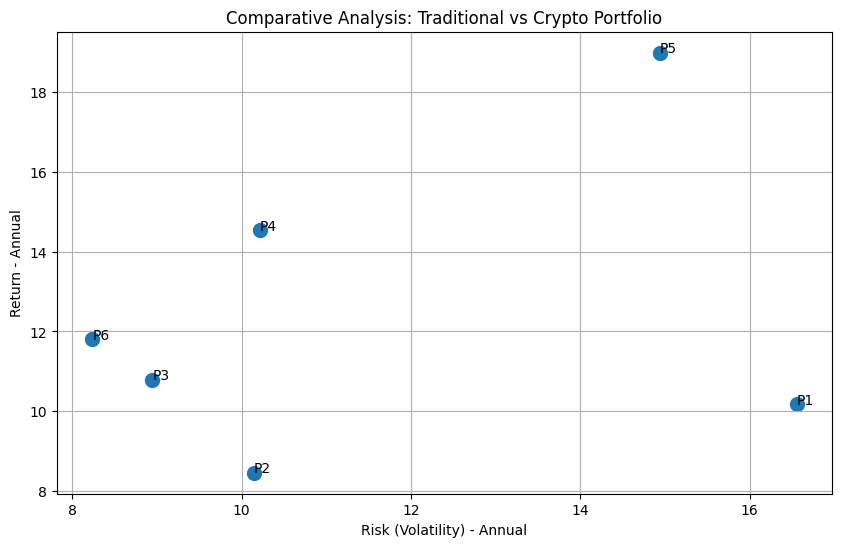

In [464]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# 6 Portfolios ko plot karo
plt.scatter(df_Port_ret['Portfolio_Risk'], df_Port_ret['Portfolio_Return'], s=100)

# Har point pe naam likh do
for i, row in df_Port_ret.iterrows():
    plt.text(row['Portfolio_Risk']+0.002, row['Portfolio_Return']+0.002, row['Portfolio'].split(':')[0])

plt.xlabel('Risk (Volatility) - Annual')
plt.ylabel('Return - Annual')
plt.title('Comparative Analysis: Traditional vs Crypto Portfolio')
plt.grid(True)
plt.show()

## Portfolio Growth

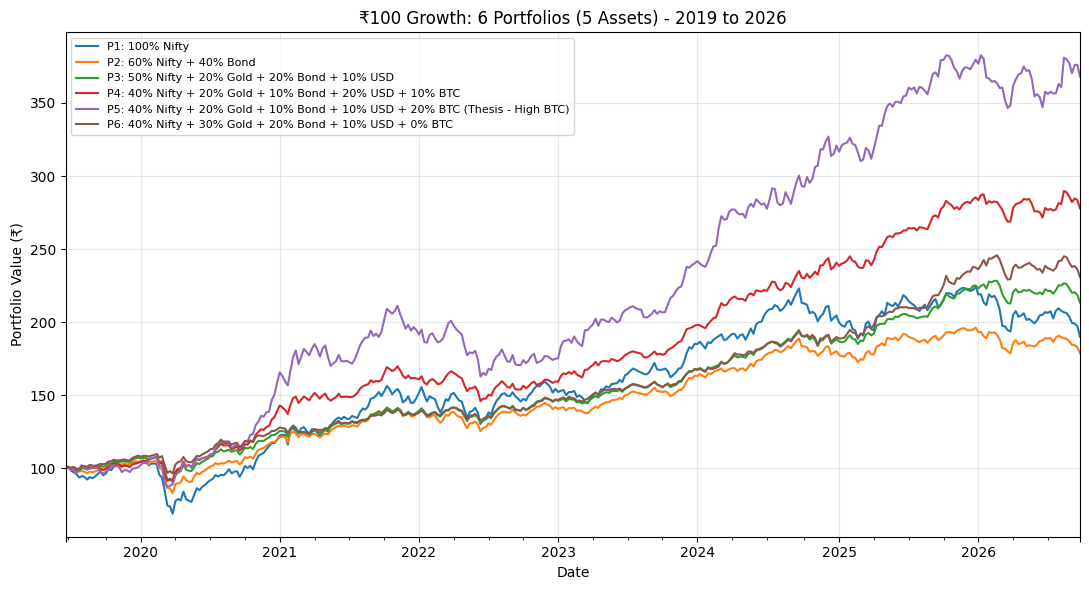

In [465]:
# --- Plot ₹100 growth ---
portfolio_returns = final_df @ pd.DataFrame(portfolios, index=assets)
((1+portfolio_returns).cumprod()*100).plot(figsize=(11,6))
plt.title('₹100 Growth: 6 Portfolios (5 Assets) - 2019 to 2026')
plt.ylabel('Portfolio Value (₹)')
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# EFFICIENT FRONTIER


In [466]:
import numpy as np
import pandas as pd

Rf = 0.065                                   # same risk-free rate as your portfolio table

# re-create the asset-level inputs here, so later cells can't break this one
ann_ret = final_df.mean() * 52               # 5-asset annual return (Series)
cov_ann = final_df.cov() * 52                # 5x5 annual covariance (DataFrame)

rng  = np.random.default_rng(42)             # fixed seed -> same chart every run
W_mc = rng.dirichlet(np.ones(len(ann_ret)), 10_000)              # 10,000 random long-only portfolios
ret  = W_mc @ ann_ret.values
vol  = np.sqrt(np.einsum('ij,jk,ik->i', W_mc, cov_ann.values, W_mc))

results_df = pd.DataFrame({'Return': ret * 100,                  # already in %
                           'Risk':   vol * 100,
                           'Sharpe': (ret - Rf) / vol})          # Sharpe with risk-free rate

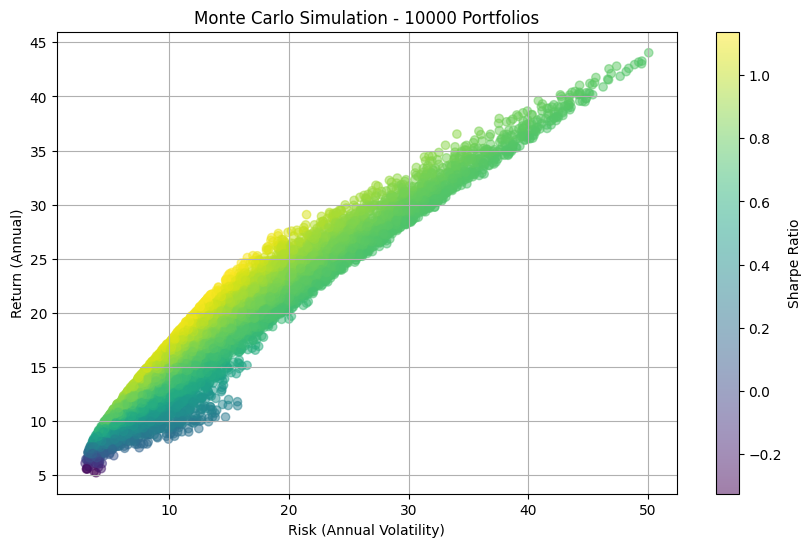

In [467]:


plt.figure(figsize=(10,6))
plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Risk (Annual Volatility)')
plt.ylabel('Return (Annual)')
plt.title('Monte Carlo Simulation - 10000 Portfolios')
plt.grid(True)
plt.show()

In [468]:
from scipy.optimize import minimize

Rf  = 0.065                                   # same risk-free rate as elsewhere
mu  = final_df.mean().values * 52             # 5-asset annual return
cov = final_df.cov().values * 52              # 5x5 annual covariance
n   = len(mu)

port_vol = lambda w: np.sqrt(w @ cov @ w)
bounds   = [(0, 1)] * n
budget   = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

def solve(obj, *extra, x0=None):
    return minimize(obj, np.ones(n)/n if x0 is None else x0, method='SLSQP',
                    bounds=bounds, constraints=[budget, *extra])

w_minvar = solve(port_vol).x                                    # global minimum-variance portfolio
w_maxsh  = solve(lambda w: -(w @ mu - Rf) / port_vol(w)).x      # maximum-Sharpe portfolio

targets = np.linspace(w_minvar @ mu, mu.max(), 50)              # efficient branch only
frontier_vol, x = [], w_minvar
for t in targets:
    r = solve(port_vol, {'type': 'eq', 'fun': lambda w, t=t: w @ mu - t}, x0=x)
    frontier_vol.append(r.fun if r.success else np.nan)
    if r.success: x = r.x                                       # warm start for next target

print('Min-variance %:', dict(zip(final_df.columns, (w_minvar * 100).round(1))))
print('Max-Sharpe   %:', dict(zip(final_df.columns, (w_maxsh  * 100).round(1))))

Min-variance %: {'BTC': np.float64(0.0), 'Gold': np.float64(1.1), 'Bond': np.float64(43.5), 'USDINR': np.float64(47.8), 'Nifty': np.float64(7.6)}
Max-Sharpe   %: {'BTC': np.float64(15.9), 'Gold': np.float64(81.6), 'Bond': np.float64(0.0), 'USDINR': np.float64(0.0), 'Nifty': np.float64(2.5)}


In [469]:
print(results_df[['Risk', 'Return']].max())

Risk      50.050685
Return    44.034576
dtype: float64


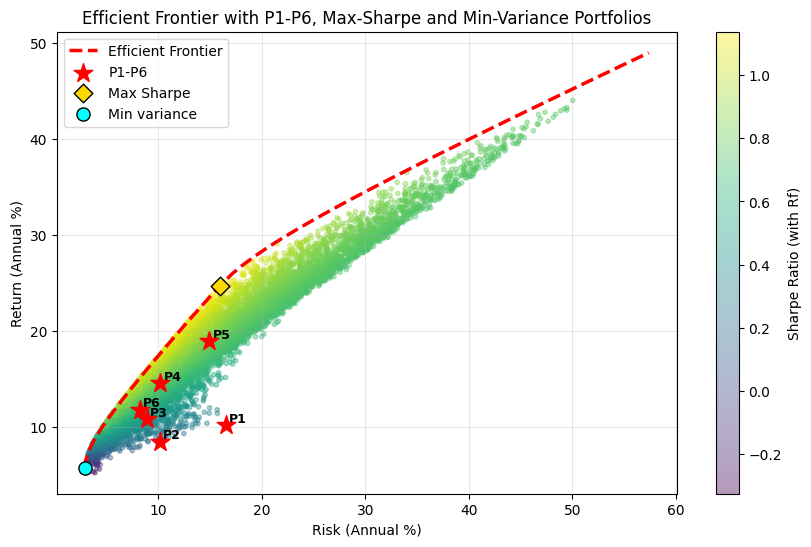

In [470]:
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe'],
            cmap='viridis', alpha=0.4, s=10)
plt.colorbar(label='Sharpe Ratio (with Rf)')

plt.plot(np.array(frontier_vol) * 100, targets * 100, 'r--', lw=2.5, label='Efficient Frontier')
plt.scatter(df_Port_ret['Portfolio_Risk'], df_Port_ret['Portfolio_Return'],
            color='red', marker='*', s=200, zorder=5, label='P1-P6')
for i, row in df_Port_ret.iterrows():
    plt.text(row['Portfolio_Risk'] + 0.3, row['Portfolio_Return'] + 0.3, f'P{i+1}',
             fontsize=9, fontweight='bold')

# the two key portfolios (same cell, same figure)
plt.scatter(port_vol(w_maxsh) * 100, (w_maxsh @ mu) * 100, marker='D', c='gold',
            edgecolor='k', s=90, zorder=6, label='Max Sharpe')
plt.scatter(port_vol(w_minvar) * 100, (w_minvar @ mu) * 100, c='cyan',
            edgecolor='k', s=90, zorder=6, label='Min variance')

plt.xlabel('Risk (Annual %)'); plt.ylabel('Return (Annual %)')
plt.title('Efficient Frontier with P1-P6, Max-Sharpe and Min-Variance Portfolios')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

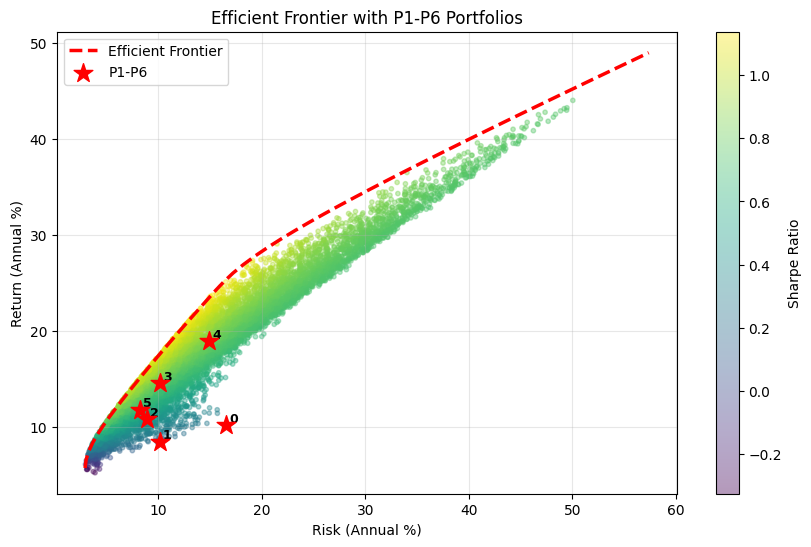

In [471]:

# Final Plot
plt.figure(figsize=(10,6))
plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis', alpha=0.4, s=10)
plt.colorbar(label='Sharpe Ratio')
plt.plot(np.array(frontier_vol)*100, targets*100, 'r--', linewidth=2.5, label='Efficient Frontier')
plt.scatter(df_Port_ret['Portfolio_Risk'], df_Port_ret['Portfolio_Return'], color='red', marker='*', s=200, label='P1-P6', zorder=5)

for i, row in df_Port_ret.iterrows():
    plt.text(row['Portfolio_Risk']+0.3, row['Portfolio_Return']+0.3, i, fontsize=9, fontweight='bold')

plt.xlabel('Risk (Annual %)')
plt.ylabel('Return (Annual %)')
plt.title('Efficient Frontier with P1-P6 Portfolios')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

ann_ret: [0.49000421 0.20342947 0.05891053 0.04504842 0.10174211]
results_df head: [[24.23059113 19.52487326]]


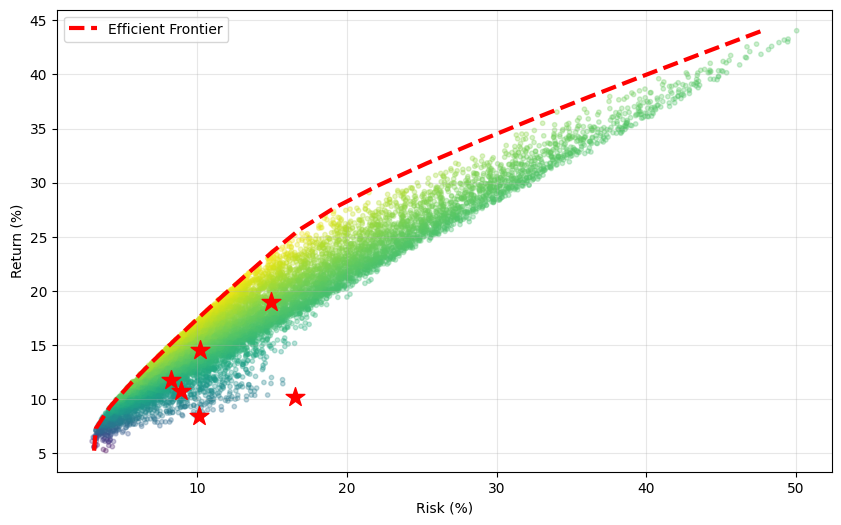

In [472]:
# 1. Check - ye dono print hone chahiye
print("ann_ret:", ann_ret.values)
print("results_df head:", results_df[['Return','Risk']].head(1).values)

# 2. Frontier calculate (sirf 20 points, fast)
from scipy.optimize import minimize
targets = np.linspace(results_df['Return'].min(), results_df['Return'].max(), 20)
f_risk = []
for t in targets:
    # t ab % me hai, isliye ann_ret*100 se compare karenge
    cons = ({'type':'eq','fun': lambda w: np.sum(w)-1},
            {'type':'eq','fun': lambda w: np.dot(w, ann_ret)*100 - t})
    res = minimize(lambda w: np.sqrt(w @ cov_ann @ w)*100,
                   np.array([1/len(ann_ret)]*len(ann_ret)),
                   method='SLSQP', bounds=tuple((0,1) for _ in range(len(ann_ret))),
                   constraints=cons)
    f_risk.append(res.fun if res.success else None)

# 3. Plot
plt.figure(figsize=(10,6))
plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis', alpha=0.3, s=10)
plt.plot(f_risk, targets, 'r--', linewidth=3, label='Efficient Frontier')
plt.scatter(df_Port_ret['Portfolio_Risk'], df_Port_ret['Portfolio_Return'], color='red', marker='*', s=200, zorder=5)
plt.xlabel('Risk (%)'); plt.ylabel('Return (%)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## Analysis


In [473]:
Rf   = 0.065                                      # annual risk-free rate (decimal)
rf_w = (1 + Rf) ** (1 / 52) - 1                   # weekly equivalent
AS   = ['BTC', 'Gold', 'Bond', 'USDINR', 'Nifty'] # same order as your weight lists

W  = pd.DataFrame(portfolios, index=AS).T         # portfolios x assets
pr = final_df[AS] @ W.T                           # weekly portfolio returns (constant mix)
mk = final_df['Nifty']                            # market benchmark for beta/alpha/Treynor

cov = final_df[AS].cov().values * 52                                    # annual risk-free rate (decimal)
rf_w = Rf / 52                                    # weekly rate, consistent with the x 52 annualisation
AS   = ['BTC', 'Gold', 'Bond', 'USDINR', 'Nifty'] # same order as your weight lists

W  = pd.DataFrame(portfolios, index=AS).T         # portfolios x assets
pr = final_df[AS] @ W.T                           # weekly portfolio returns (constant mix)
mk = final_df['Nifty']                            # market benchmark for beta/alpha/Treynor

cov = final_df[AS].cov().values * 52
Wm  = W.values
pv  = np.einsum('ij,jk,ik->i', Wm, cov, Wm)       # portfolio variance

def ratios(r):
    ex, exm = r - rf_w, mk - rf_w
    vol    = r.std() * np.sqrt(52)
    beta   = ex.cov(exm) / exm.var()
    alpha  = (ex.mean() - beta * exm.mean()) * 52                # Jensen's alpha, annual
    wealth = (1 + r).cumprod()
    mdd    = (wealth / wealth.cummax().clip(lower=1) - 1).min()  # initial capital counts as the first peak
    cagr   = wealth.iloc[-1] ** (52 / len(r)) - 1
    down   = np.sqrt((ex.clip(upper=0) ** 2).mean() * 52)        # downside deviation
    te     = (r - mk).std() * np.sqrt(52)                        # tracking error vs Nifty
    var    = r.quantile(.05)
    return pd.Series({
        'Return%': r.mean() * 52 * 100, 'CAGR%': cagr * 100, 'Vol%': vol * 100,
        'Sharpe':   ex.mean() * 52 / vol,
        'Treynor%': ex.mean() * 52 / beta * 100,
        'Alpha%':   alpha * 100, 'Beta': beta,
        'Sortino':  ex.mean() * 52 / down,
        'Calmar':   cagr / -mdd, 'MaxDD%': mdd * 100,
        'InfoRatio': (r.mean() - mk.mean()) * 52 / te if te > 1e-12 else np.nan,
        'VaR95%': var * 100, 'CVaR95%': r[r <= var].mean() * 100,
        'Skew': r.skew(), 'ExKurt': r.kurt()})

ratio_df = pr.apply(ratios).T
ratio_df['DivRatio']  = Wm @ np.sqrt(np.diag(cov)) / np.sqrt(pv)            # diversification ratio
ratio_df['BTC_w%']    = W['BTC'] * 100
ratio_df['BTC_risk%'] = Wm[:, 0] * (Wm @ cov)[:, 0] / pv * 100              # BTC's share of portfolio risk
(ratio_df.round(2) + 0.0).transpose()                                        # '+ 0.0' after rounding avoids "-0.00"
Wm  = W.values
pv  = np.einsum('ij,jk,ik->i', Wm, cov, Wm)       # portfolio variance

def ratios(r):
    ex, exm = r - rf_w, mk - rf_w
    vol    = r.std() * np.sqrt(52)
    beta   = ex.cov(exm) / exm.var()
    alpha  = (ex.mean() - beta * exm.mean()) * 52                # Jensen's alpha, annual
    wealth = (1 + r).cumprod()
    mdd    = (wealth / wealth.cummax() - 1).min()
    cagr   = wealth.iloc[-1] ** (52 / len(r)) - 1
    down   = np.sqrt((ex.clip(upper=0) ** 2).mean() * 52)        # downside deviation
    te     = (r - mk).std() * np.sqrt(52)                        # tracking error vs Nifty
    var    = r.quantile(.05)
    return pd.Series({
        'Return%': r.mean() * 52 * 100, 'CAGR%': cagr * 100, 'Vol%': vol * 100,
        'Sharpe':   ex.mean() * 52 / vol,
        'Treynor%': ex.mean() * 52 / beta * 100,
        'Alpha%':   alpha * 100 + 0.0, 'Beta': beta,
        'Sortino':  ex.mean() * 52 / down,
        'Calmar':   cagr / -mdd, 'MaxDD%': mdd * 100,
        'InfoRatio': (r.mean() - mk.mean()) * 52 / te if te > 1e-12 else np.nan,
        'VaR95%': var * 100, 'CVaR95%': r[r <= var].mean() * 100,
        'Skew': r.skew(), 'ExKurt': r.kurt()})

ratio_df = pr.apply(ratios).T
ratio_df['DivRatio']  = Wm @ np.sqrt(np.diag(cov)) / np.sqrt(pv)            # diversification ratio
ratio_df['BTC_w%']    = W['BTC'] * 100
ratio_df['BTC_risk%'] = Wm[:, 0] * (Wm @ cov)[:, 0] / pv * 100 + 0.0        # BTC's share of portfolio risk
ratio_df.round(2).transpose()

,P1: 100% Nifty,P2: 60% Nifty + 40% Bond,P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD,P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC,P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC),P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC
Return%,10.17,8.46,10.78,14.53,18.98,11.80
CAGR%,9.20,8.26,10.93,15.01,19.52,12.13
Vol%,16.56,10.14,8.94,10.21,14.93,8.24
Sharpe,0.22,0.19,0.48,0.79,0.84,0.64
Treynor%,3.67,3.25,8.51,17.32,22.92,12.95
Alpha%,-0.00,-0.25,2.44,6.33,10.48,3.80
Beta,1.00,0.60,0.50,0.46,0.54,0.41
Sortino,0.31,0.27,0.68,1.16,1.25,0.93
Calmar,0.27,0.39,0.68,1.00,0.85,0.99
MaxDD%,-34.56,-20.99,-16.18,-14.95,-22.89,-12.30


## sensityvity analysis


In [474]:
# ---- Scenario analysis: cumulative compounded return of each portfolio per scenario ----
W = pd.DataFrame(portfolios, index=assets).T                      # portfolios x assets
short = {name: name.split(':')[0] for name in portfolios}         # P1, P2, ... for compact tables

# Hypothetical 2008-type shock per asset (assumptions, not observed data; BTC did not exist in 2008)
shock_2008 = {'BTC': -0.60, 'Gold': 0.05, 'Bond': 0.06, 'USDINR': 0.05, 'Nifty': -0.52}

# Historical windows inside the dataset (weekly bars are labelled by their Monday start date)
windows = {
    'COVID Crash':         ('2020-02-20', '2020-03-23'),
    'Post-COVID Bull':     ('2020-04-01', '2021-10-31'),
    'Rate Hike Bear 2022': ('2022-01-01', '2022-12-31'),
    '2023-24 Bull Run':    ('2023-01-01', '2024-12-31'),
}

results = {}
results['2008 GFC (stress)'] = pd.Series(
    W.values @ np.array([shock_2008[a] for a in assets]), index=W.index) * 100

for scen_name, (start, end) in windows.items():
    window = final_df.loc[start:end]
    if window.empty:
        print(f'Skipped {scen_name}: no data in window')
        continue
    results[scen_name] = ((1 + window @ W.T).prod() - 1) * 100    # cumulative return, %

scenario_df = pd.DataFrame(results).T.rename(columns=short)
scenario_df.round(2)

,P1,P2,P3,P4,P5,P6
2008 GFC (stress),-52.00,-28.80,-23.30,-24.20,-30.70,-17.60
COVID Crash,-28.31,-17.64,-13.92,-14.21,-18.09,-10.69
Post-COVID Bull,118.55,66.54,53.53,80.55,130.86,42.97
Rate Hike Bear 2022,4.32,3.35,6.45,-1.25,-10.13,7.30
2023-24 Bull Run,32.56,26.98,28.32,50.93,83.33,29.01


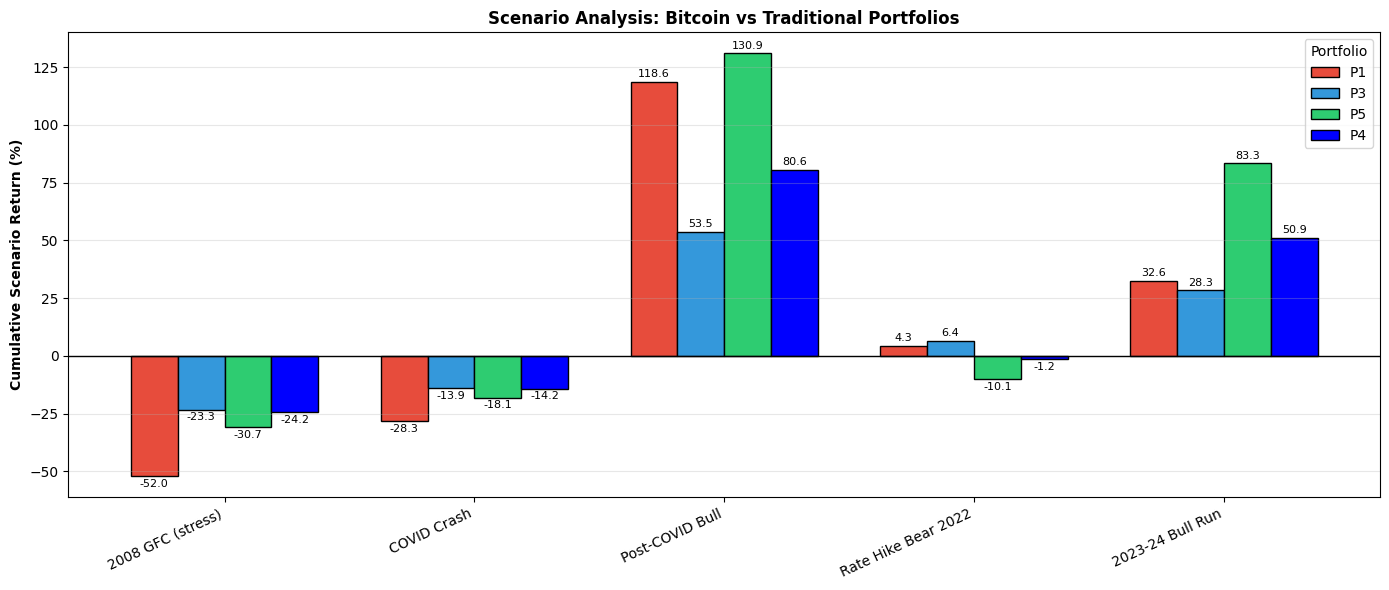

In [475]:
# ---- Scenario chart: benchmark (P1), diversified traditional (P3) and high-BTC (P5) ----
plot_df = scenario_df[['P1', 'P3', 'P5','P4']]

ax = plot_df.plot(kind='bar', figsize=(14, 6), width=0.75, edgecolor='black',
                  color=['#e74c3c', '#3498db', '#2ecc71','blue'])

# Value labels on every bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)

ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Cumulative Scenario Return (%)', fontweight='bold')
ax.set_xlabel('')
ax.set_title('Scenario Analysis: Bitcoin vs Traditional Portfolios', fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Portfolio')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Scenario_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Scenario Analysis

In [476]:
# ---- Scenario analysis: cumulative compounded return per portfolio ----
W = pd.DataFrame(portfolios, index=assets).T                      # portfolios x assets
short = {name: name.split(':')[0] for name in portfolios}         # P1, P2, ...

# Hypothetical 2008-type shock (assumptions; BTC did not exist in 2008)
shock_2008 = {'BTC': -0.60, 'Gold': 0.05, 'Bond': 0.06, 'USDINR': 0.05, 'Nifty': -0.52}

# Historical windows that lie inside the dataset
windows = {
    'COVID Crash':         ('2020-02-20', '2020-03-23'),
    'Post-COVID Bull':     ('2020-04-01', '2021-10-31'),
    'Rate Hike Bear 2022': ('2022-01-01', '2022-12-31'),
    '2023-24 Bull Run':    ('2023-01-01', '2024-12-31'),
}

results = {'2008 GFC (stress)': pd.Series(
    W.values @ np.array([shock_2008[a] for a in assets]), index=W.index) * 100}

for scen_name, (start, end) in windows.items():
    window = final_df.loc[start:end]
    if window.empty:
        print(f'Skipped {scen_name}: no data in window')
        continue
    results[scen_name] = ((1 + window @ W.T).prod() - 1) * 100

scenario_df = pd.DataFrame(results).T.rename(columns=short)
scenario_df.round(2)

,P1,P2,P3,P4,P5,P6
2008 GFC (stress),-52.00,-28.80,-23.30,-24.20,-30.70,-17.60
COVID Crash,-28.31,-17.64,-13.92,-14.21,-18.09,-10.69
Post-COVID Bull,118.55,66.54,53.53,80.55,130.86,42.97
Rate Hike Bear 2022,4.32,3.35,6.45,-1.25,-10.13,7.30
2023-24 Bull Run,32.56,26.98,28.32,50.93,83.33,29.01


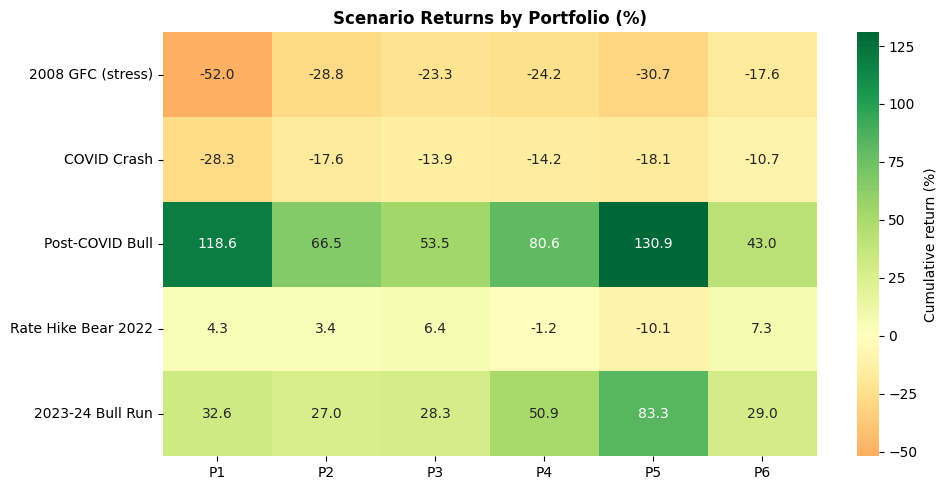

In [477]:
plt.figure(figsize=(10, 5))
sns.heatmap(scenario_df[['P1', 'P2', 'P3', 'P4', 'P5', 'P6']].round(1),
            annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Cumulative return (%)'})
plt.title('Scenario Returns by Portfolio (%)', fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('Scenario_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

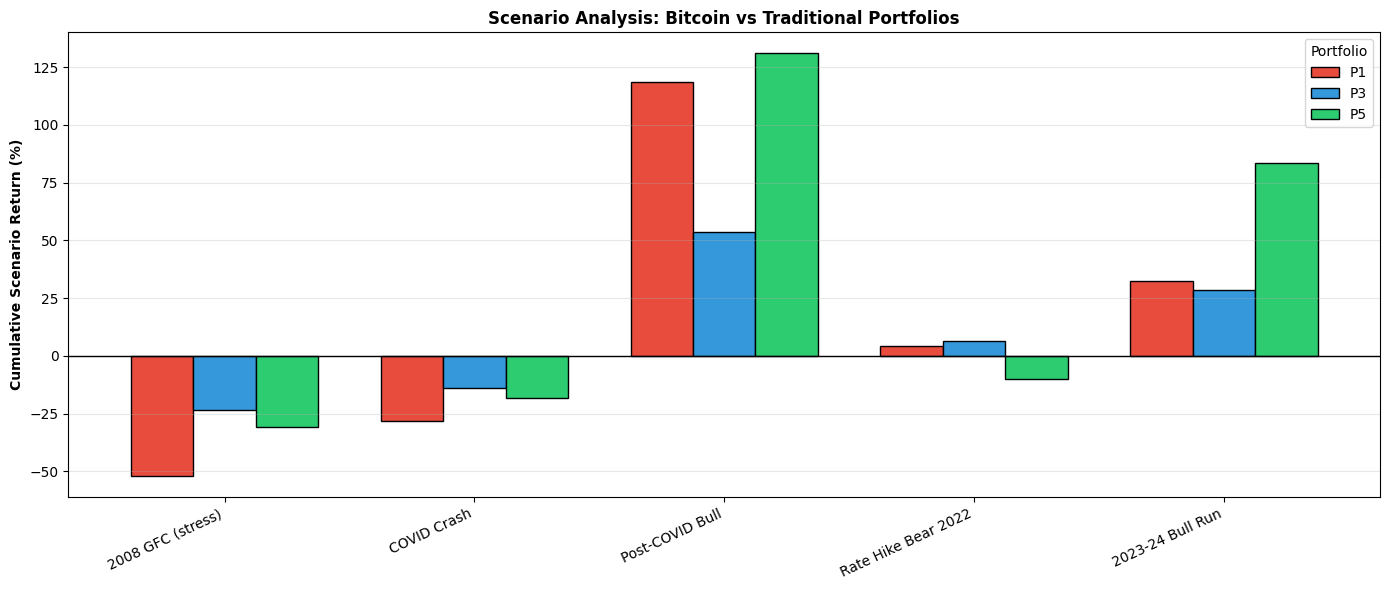

In [478]:
# ---- Scenario analysis: cumulative compounded return per portfolio ----
W = pd.DataFrame(portfolios, index=assets).T
short = {name: name.split(':')[0] for name in portfolios}

# Hypothetical 2008-type shock (assumptions; BTC did not exist in 2008)
shock_2008 = {'BTC': -0.60, 'Gold': 0.05, 'Bond': 0.06, 'USDINR': 0.05, 'Nifty': -0.52}

windows = {
    'COVID Crash':         ('2020-02-20', '2020-03-23'),
    'Post-COVID Bull':     ('2020-04-01', '2021-10-31'),
    'Rate Hike Bear 2022': ('2022-01-01', '2022-12-31'),
    '2023-24 Bull Run':    ('2023-01-01', '2024-12-31'),
}

results = {'2008 GFC (stress)': pd.Series(
    W.values @ np.array([shock_2008[a] for a in assets]), index=W.index) * 100}

for scen_name, (start, end) in windows.items():
    window = final_df.loc[start:end]
    if window.empty:
        print(f'Skipped {scen_name}: no data in window')
        continue
    results[scen_name] = ((1 + window @ W.T).prod() - 1) * 100

scenario_df = pd.DataFrame(results).T.rename(columns=short)

ax = scenario_df[['P1', 'P3', 'P5']].plot(kind='bar', figsize=(14, 6),
                                          color=['#e74c3c', '#3498db', '#2ecc71'],
                                          edgecolor='black', width=0.75)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Cumulative Scenario Return (%)', fontweight='bold')
ax.set_title('Scenario Analysis: Bitcoin vs Traditional Portfolios', fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Portfolio')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Scenario_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [479]:
def div_benefit(w, cov):
    # Diversification Ratio > 1 = fayda hai
    w_vol = np.sum(np.array(w) * np.sqrt(np.diag(cov)))
    p_vol = np.sqrt(np.array(w) @ cov @ np.array(w))
    return w_vol / p_vol

for p, w in portfolios.items():
    dr = div_benefit(w, cov_ann)
    # P1 se kitna improvement
    # Corrected the key for P1
    improvement = (dr / div_benefit(portfolios['P1: 100% Nifty'], cov_ann) - 1)*100
    print(f"{p}: Div Ratio={dr:.2f}, Benefit vs P1 = {improvement:.1f}%")

P1: 100% Nifty: Div Ratio=1.00, Benefit vs P1 = 0.0%
P2: 60% Nifty + 40% Bond: Div Ratio=1.16, Benefit vs P1 = 16.0%
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD: Div Ratio=1.41, Benefit vs P1 = 41.4%
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD + 10% BTC: Div Ratio=1.64, Benefit vs P1 = 64.0%
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD + 20% BTC (Thesis - High BTC): Div Ratio=1.47, Benefit vs P1 = 47.4%
P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD + 0% BTC: Div Ratio=1.51, Benefit vs P1 = 51.5%


# Risk Metrics

In [480]:
# ---- BTC allocation sweep: BTC from 0% to 20%, remainder in a fixed traditional mix ----
base_mix  = {'Nifty': 0.5, 'Gold': 0.3, 'Bond': 0.2}     # split of the non-BTC part of the portfolio
btc_range = np.arange(0, 0.21, 0.01)

rows = []
for b in btc_range:
    w = pd.Series({**{k: v * (1 - b) for k, v in base_mix.items()}, 'BTC': b})
    r = (final_df[w.index] * w).sum(axis=1)                # weights matched to assets by name
    ret, vol = r.mean() * 52, r.std() * np.sqrt(52)
    rows.append([round(b * 100), ret * 100, vol * 100, (ret - Rf) / vol])

sweep = pd.DataFrame(rows, columns=['BTC_%', 'Return_%', 'Vol_%', 'Sharpe'])

# Reference points calculated from the data (not typed in)
best_btc    = sweep.loc[sweep['Sharpe'].idxmax(), 'BTC_%']                        # highest Sharpe
vol_neutral = sweep.loc[sweep['Vol_%'] <= sweep.loc[0, 'Vol_%'], 'BTC_%'].max()   # last weight with no extra volatility
print(f'Sharpe-maximising BTC weight : {best_btc:.0f}%')
print(f'Volatility-neutral BTC limit : {vol_neutral:.0f}%')
sweep.round(2)

Sharpe-maximising BTC weight : 19%
Volatility-neutral BTC limit : 0%


,BTC_%,Return_%,Vol_%,Sharpe
0,0,12.37,9.76,0.60
1,1,12.73,9.80,0.64
2,2,13.10,9.88,0.67
3,3,13.47,9.98,0.70
4,4,13.83,10.12,0.72
5,5,14.20,10.28,0.75
6,6,14.57,10.47,0.77
7,7,14.93,10.69,0.79
8,8,15.30,10.93,0.81
9,9,15.67,11.19,0.82


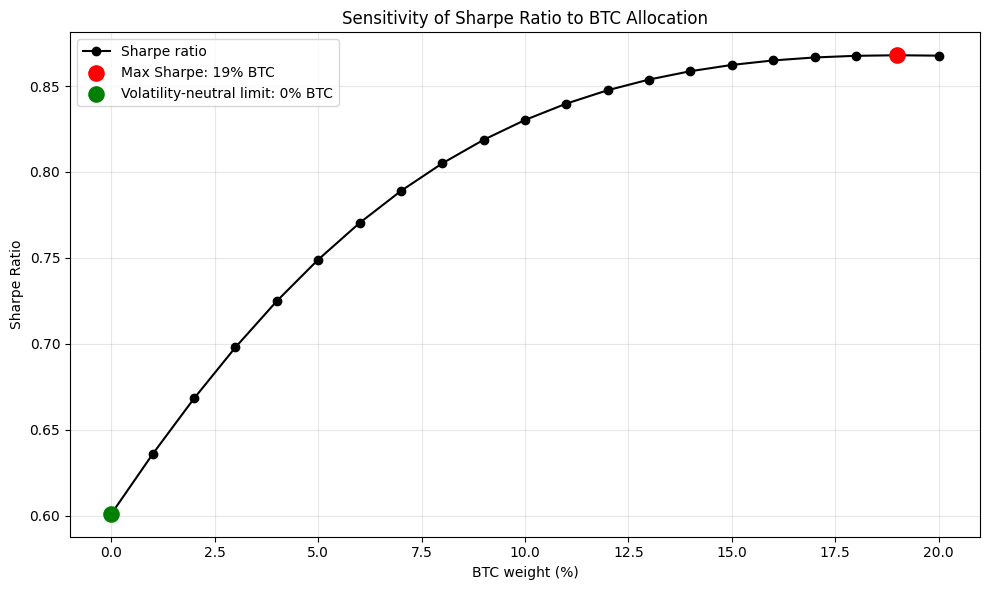

In [481]:
# ---- Sharpe ratio vs BTC allocation, with the two reference points marked ----
plt.figure(figsize=(10, 6))
plt.plot(sweep['BTC_%'], sweep['Sharpe'], 'o-', color='black', label='Sharpe ratio')

# Reference points calculated in the sweep cell
sharpe_best = sweep.loc[sweep['BTC_%'] == best_btc, 'Sharpe'].iloc[0]
sharpe_neut = sweep.loc[sweep['BTC_%'] == vol_neutral, 'Sharpe'].iloc[0]
plt.scatter(best_btc, sharpe_best, color='red', s=120, zorder=5,
            label=f'Max Sharpe: {best_btc:.0f}% BTC')
plt.scatter(vol_neutral, sharpe_neut, color='green', s=120, zorder=5,
            label=f'Volatility-neutral limit: {vol_neutral:.0f}% BTC')

plt.xlabel('BTC weight (%)')
plt.ylabel('Sharpe Ratio')
plt.title('Sensitivity of Sharpe Ratio to BTC Allocation')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Min_BTC_Range.png', dpi=300)
plt.show()

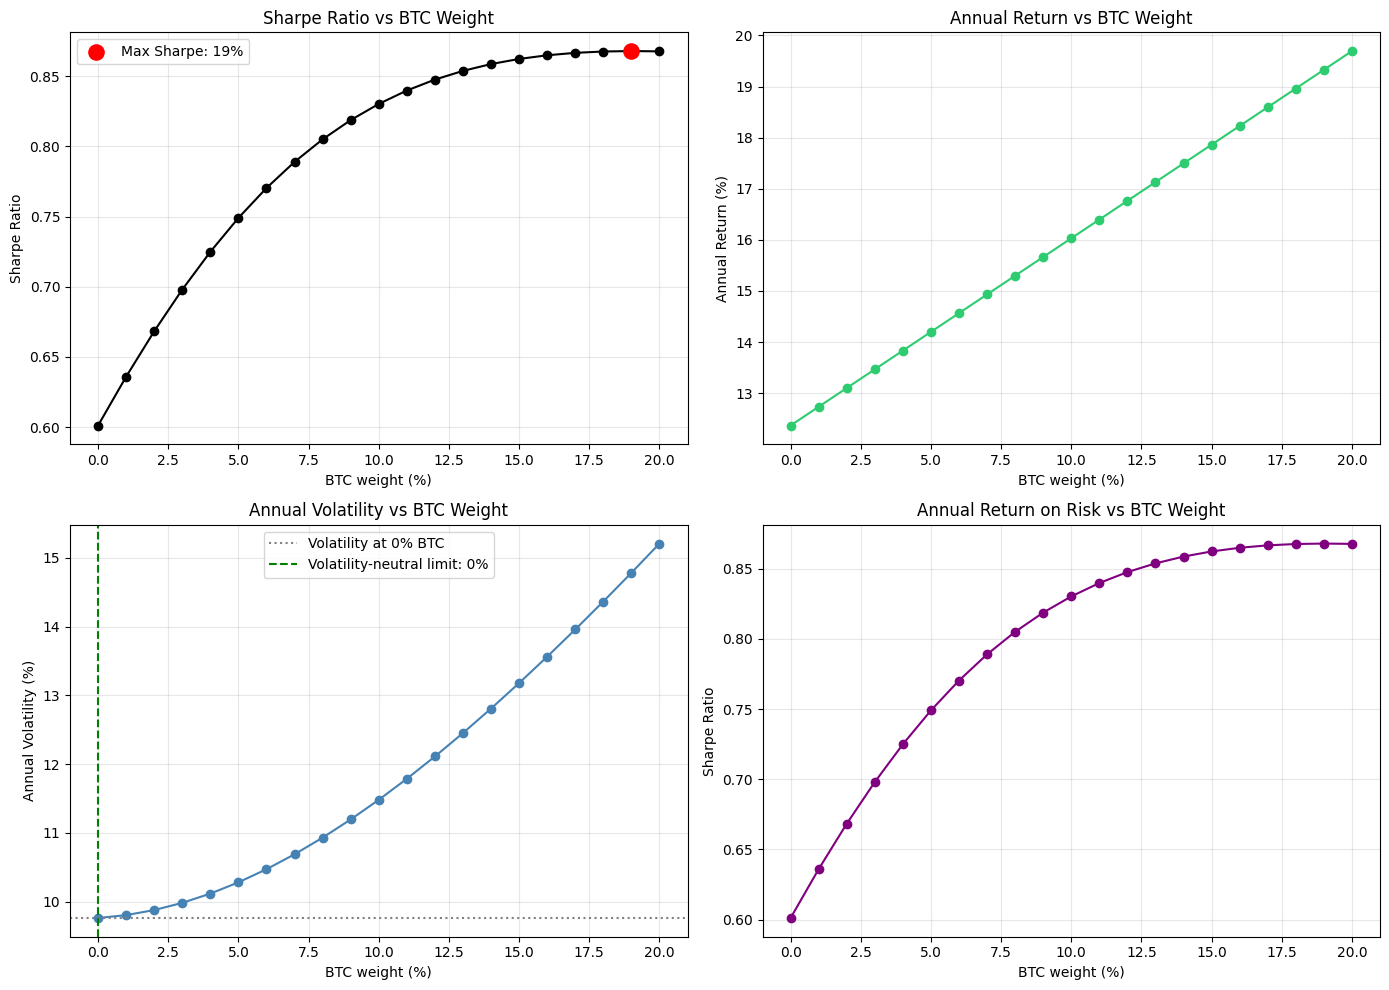

In [482]:
# ---- Full BTC allocation analysis: four panels ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sharpe ratio
ax = axes[0, 0]
ax.plot(sweep['BTC_%'], sweep['Sharpe'], 'o-', color='black')
ax.scatter(best_btc, sweep.loc[sweep['BTC_%'] == best_btc, 'Sharpe'].iloc[0],
           color='red', s=120, zorder=5, label=f'Max Sharpe: {best_btc:.0f}%')
ax.set_title('Sharpe Ratio vs BTC Weight')
ax.set_xlabel('BTC weight (%)')
ax.set_ylabel('Sharpe Ratio')
ax.legend()
ax.grid(alpha=0.3)

# 2. Annual return
ax = axes[0, 1]
ax.plot(sweep['BTC_%'], sweep['Return_%'], 'o-', color='#2ecc71')
ax.set_title('Annual Return vs BTC Weight')
ax.set_xlabel('BTC weight (%)')
ax.set_ylabel('Annual Return (%)')
ax.grid(alpha=0.3)

# 3. Annual volatility with the volatility-neutral limit
ax = axes[1, 0]
ax.plot(sweep['BTC_%'], sweep['Vol_%'], 'o-', color='steelblue')
ax.axhline(sweep.loc[0, 'Vol_%'], color='grey', linestyle=':', label='Volatility at 0% BTC')
ax.axvline(vol_neutral, color='green', linestyle='--', label=f'Volatility-neutral limit: {vol_neutral:.0f}%')
ax.set_title('Annual Volatility vs BTC Weight')
ax.set_xlabel('BTC weight (%)')
ax.set_ylabel('Annual Volatility (%)')
ax.legend()
ax.grid(alpha=0.3)

# 4. Annual return on risk (Sharpe Ratio)
ax = axes[1, 1]
ax.plot(sweep['BTC_%'], sweep['Sharpe'], 'o-', color='purple')
ax.set_title('Annual Return on Risk vs BTC Weight')
ax.set_xlabel('BTC weight (%)')
ax.set_ylabel('Sharpe Ratio')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Full_BTC_Analysis.png', dpi=300)
plt.show()

## VaR and CVaR

In [483]:
from scipy.stats import norm

# ---- Tail risk: weekly historical VaR / CVaR and parametric VaR ----
def var_cvar(r, conf):
    """Historical VaR and CVaR in % (negative = loss) at the given confidence level."""
    var = r.quantile(1 - conf)
    return var * 100, r[r <= var].mean() * 100

portfolio_returns = final_df @ W.T                      # weekly portfolio returns (N x 6)

rows = []
for name, r in portfolio_returns.items():
    v95, c95 = var_cvar(r, 0.95)
    v99, c99 = var_cvar(r, 0.99)
    v95_param = (r.mean() + r.std() * norm.ppf(0.05)) * 100   # parametric (normal) VaR 95%
    rows.append([name, W.loc[name, 'BTC'] * 100, v95, c95, v99, c99, v95_param])

df_risk = pd.DataFrame(rows, columns=['Portfolio', 'BTC_w%', 'VaR 95% (Hist)', 'CVaR 95% (Hist)',
                                      'VaR 99% (Hist)', 'CVaR 99% (Hist)',
                                      'VaR 95% (Param)']).set_index('Portfolio')
print(df_risk.round(2))
df_risk.round(2).to_excel('VaR_CVaR_Risk_Exposure.xlsx')

                                                    BTC_w%  VaR 95% (Hist)  \
Portfolio                                                                    
P1: 100% Nifty                                         0.0           -2.94   
P2: 60% Nifty + 40% Bond                               0.0           -1.96   
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD          0.0           -1.60   
P4: 40% Nifty + 20% Gold + 10% Bond + 20% USD +...    10.0           -1.94   
P5: 40% Nifty + 20% Gold + 10% Bond + 10% USD +...    20.0           -3.02   
P6: 40% Nifty + 30% Gold + 20% Bond + 10% USD +...     0.0           -1.61   

                                                    CVaR 95% (Hist)  \
Portfolio                                                             
P1: 100% Nifty                                                -5.24   
P2: 60% Nifty + 40% Bond                                      -3.21   
P3: 50% Nifty + 20% Gold + 20% Bond + 10% USD                 -2.85   
P4: 40% Nifty + 20% 

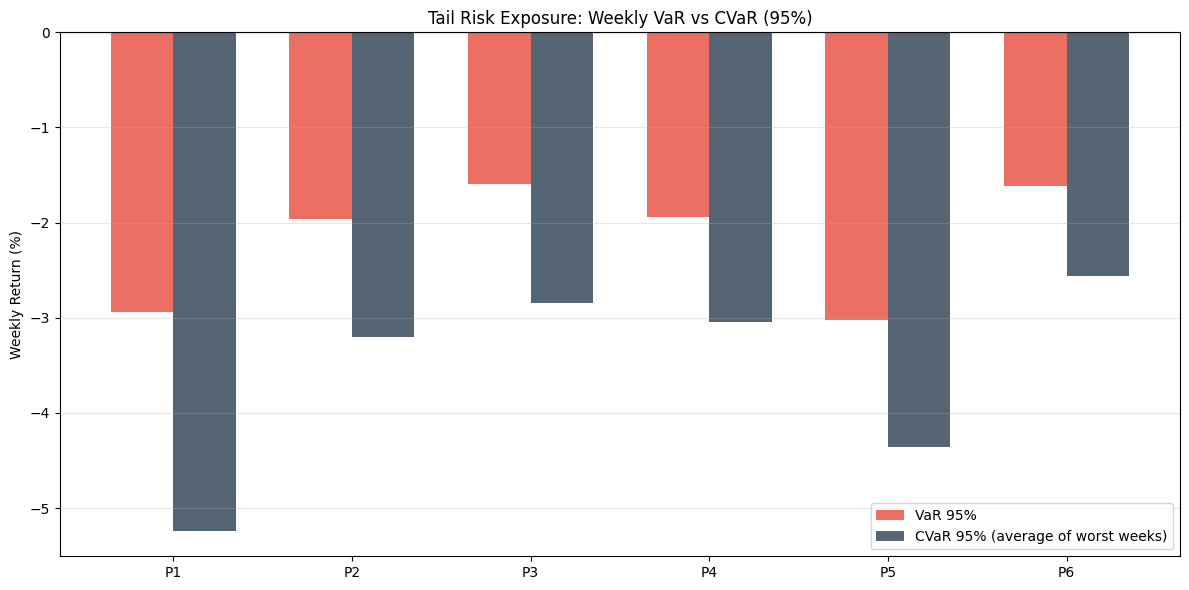

In [484]:
# ---- Chart: weekly VaR vs CVaR (95%) ----
x = np.arange(len(df_risk))
plt.figure(figsize=(12, 6))
plt.bar(x - 0.175, df_risk['VaR 95% (Hist)'],  width=0.35, label='VaR 95%', color='#e74c3c', alpha=0.8)
plt.bar(x + 0.175, df_risk['CVaR 95% (Hist)'], width=0.35, label='CVaR 95% (average of worst weeks)',
        color='#2c3e50', alpha=0.8)
plt.xticks(x, [short[p] for p in df_risk.index])
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Weekly Return (%)')
plt.title('Tail Risk Exposure: Weekly VaR vs CVaR (95%)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('VaR_CVaR_Exposure.png', dpi=300)
plt.show()

## Max Sharpe Ratio


In [485]:
#Optimal Portfolio
# ---- Optimal portfolio search (long-only, weights sum to 1) ----
def annual_inputs(r):
    return (r.mean() * 52).values, (r.cov() * 52).values

def optimise(mu_a, cov_a, objective, bounds=None, extra=()):
    n = len(mu_a)
    bounds = bounds if bounds is not None else [(0, 1)] * n
    cons = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}, *extra]
    return minimize(objective, np.ones(n) / n, method='SLSQP', bounds=bounds, constraints=cons).x

def max_sharpe(mu_a, cov_a, bounds=None):
    obj = lambda w: -(w @ mu_a - Rf) / np.sqrt(w @ cov_a @ w)
    return optimise(mu_a, cov_a, obj, bounds)

def min_variance(mu_a, cov_a, target_return=None, bounds=None):
    extra = [] if target_return is None else [{'type': 'ineq', 'fun': lambda w: w @ mu_a - target_return}]
    return optimise(mu_a, cov_a, lambda w: w @ cov_a @ w, bounds, extra)

mu_a, cov_a = annual_inputs(final_df)
caps = [(0, {'BTC': 0.20, 'Gold': 0.40}.get(a, 1.0)) for a in assets]   # position limits

candidates = {
    'Max Sharpe':          max_sharpe(mu_a, cov_a),
    'Max Sharpe (capped)': max_sharpe(mu_a, cov_a, caps),
    'Min variance':        min_variance(mu_a, cov_a),
    'Min variance @ 12% return': min_variance(mu_a, cov_a, target_return=0.12),
}

def summarise(w):
    ret, vol = w @ mu_a, np.sqrt(w @ cov_a @ w)
    return ret * 100, vol * 100, (ret - Rf) / vol

opt_table = pd.DataFrame(candidates, index=assets).T * 100
opt_table[['Return%', 'Vol%', 'Sharpe']] = [summarise(w) for w in candidates.values()]
print(opt_table.round(2))

# ---- Out-of-sample check: optimise on the first 70% of weeks, evaluate on the last 30% ----
split = int(len(final_df) * 0.7)
train, test = final_df.iloc[:split], final_df.iloc[split:]
mu_t, cov_t = annual_inputs(train)

def test_sharpe(w):
    r = test @ w
    return (r.mean() * 52 - Rf) / (r.std() * np.sqrt(52))

oos = {'Max Sharpe (train-optimised)': test_sharpe(max_sharpe(mu_t, cov_t)),
       'Max Sharpe capped (train-optimised)': test_sharpe(max_sharpe(mu_t, cov_t, caps))}
oos.update({name.split(':')[0]: test_sharpe(W.loc[name].values) for name in portfolios})
print(pd.Series(oos, name='Test-period Sharpe').round(2).T)

                             BTC   Gold   Bond  USDINR  Nifty  Return%   Vol%  \
Max Sharpe                 15.94  81.59   0.00    0.00   2.47    24.66  15.92   
Max Sharpe (capped)        10.79  40.00  41.35    0.00   7.86    16.66   9.60   
Min variance                0.00   1.09  43.53   47.84   7.54     5.71   2.94   
Min variance @ 12% return   4.78  28.51  29.98   29.03   7.70    12.00   5.97   

                           Sharpe  
Max Sharpe                   1.14  
Max Sharpe (capped)          1.06  
Min variance                -0.27  
Min variance @ 12% return    0.92  
Max Sharpe (train-optimised)           1.12
Max Sharpe capped (train-optimised)    0.93
P1                                    -0.80
P2                                    -0.79
P3                                    -0.00
P4                                     0.36
P5                                     0.42
P6                                     0.46
Name: Test-period Sharpe, dtype: float64


In [489]:
# maximizing sharpe ratio

def portfolio_annual_stats(weights):
    weights = np.array(weights)
    # Calculate annual return using global mu (mean annual returns array)
    port_ann_ret = np.sum(weights * mu)
    # Calculate annual standard deviation using global cov (annual covariance matrix array)
    port_ann_std = np.sqrt(weights.T @ cov @ weights)
    # Calculate Sharpe ratio
    sharpe = (port_ann_ret - Rf) / port_ann_std

    return port_ann_ret * 100, port_ann_std * 100, sharpe

def neg_sharpe(weights):
    # The portfolio_annual_stats returns (return_pct, vol_pct, sharpe). We want to minimize -sharpe.
    return -portfolio_annual_stats(weights)[2]

n = len(final_df.columns) # Corrected from df_weekly to final_df
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(n))  # No short selling
init = [1/n]*n

optimal = minimize(neg_sharpe, init, method='SLSQP', bounds=bounds, constraints=constraints)

ann_ret_pct, ann_vol_pct, max_sharpe = portfolio_annual_stats(optimal.x)

print("\n===== ANNUAL MAX SHARPE PORTFOLIO =====")
for asset, weight in zip(final_df.columns, optimal.x): # Corrected from df_weekly to final_df
    print(f"{asset}: {weight*100:.2f}%")
print(f"\nAnnual Return: {ann_ret_pct:.2f}%")
print(f"Annual Volatility: {ann_vol_pct:.2f}%")
print(f"MAX SHARPE (Annual): {max_sharpe:.4f}")
print(f"Risk Free: {Rf*100:.2f}%") # Corrected from Rf_annual to Rf



===== ANNUAL MAX SHARPE PORTFOLIO =====
BTC: 15.94%
Gold: 81.59%
Bond: 0.00%
USDINR: 0.00%
Nifty: 2.47%

Annual Return: 24.66%
Annual Volatility: 15.92%
MAX SHARPE (Annual): 1.1407
Risk Free: 6.50%
